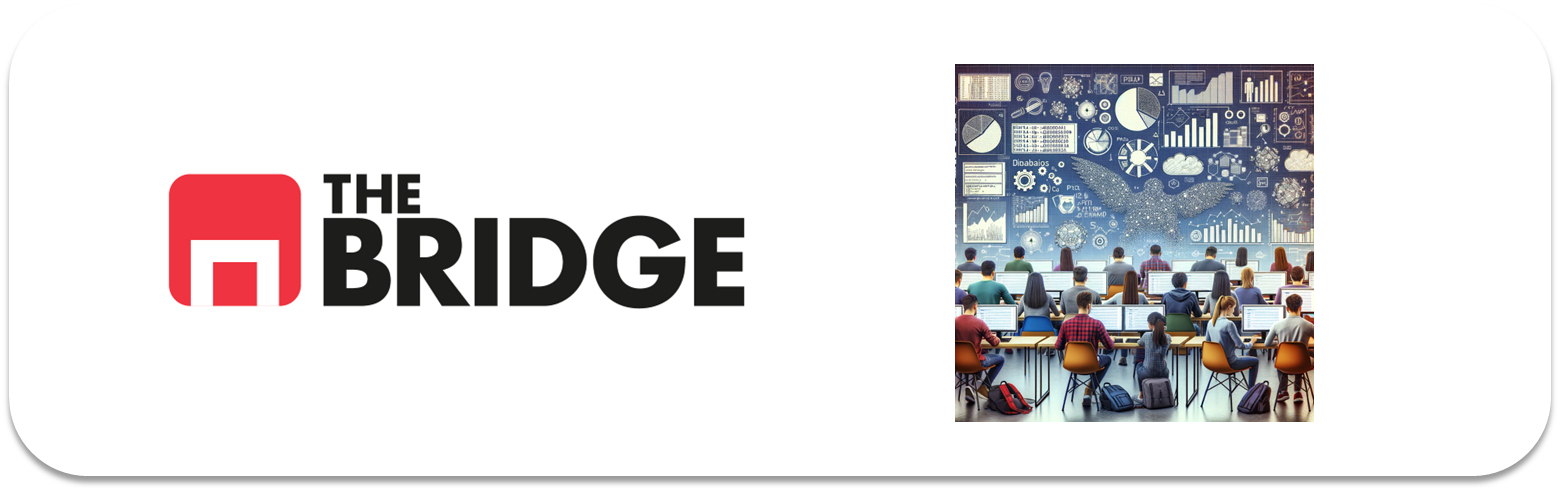

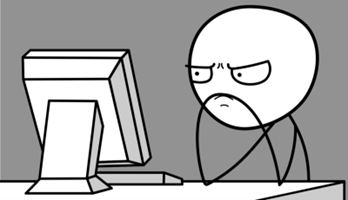

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [151]:
import numpy as np
import pandas as pd

from sklearn import linear_model, metrics, model_selection
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

En estos ejercicios vamos a repasar la regularización sobre regresión lineal obteniendo primero un modelo de regresión lineal para predecir el precio de un coche y luego los equivalentes con penalizaciones L2 (Ridge), L1 (Lasso) y con la combinación de ambas (ElasticNet)

### Ejercicio 1

Carga el dataset de partida ("./data/CarPrice_Assignment.csv") en el que tenemos diferentes modelos de coches con sus características y el precio de estos. Échale un vistazo

In [152]:
df = pd.read_csv("./data/CarPrice_Assignment.csv")
df.head()
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
unique,NaN,NaN,147,2,2,2,5,3,2,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,peugeot 504,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,6,185,168,115,96,120,202,NaN,...,NaN,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,103.000000,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000


In [153]:
df.drop(['car_ID', 'CarName'], axis=1, inplace=True)

In [154]:
df_num = df.select_dtypes(include=[np.number])

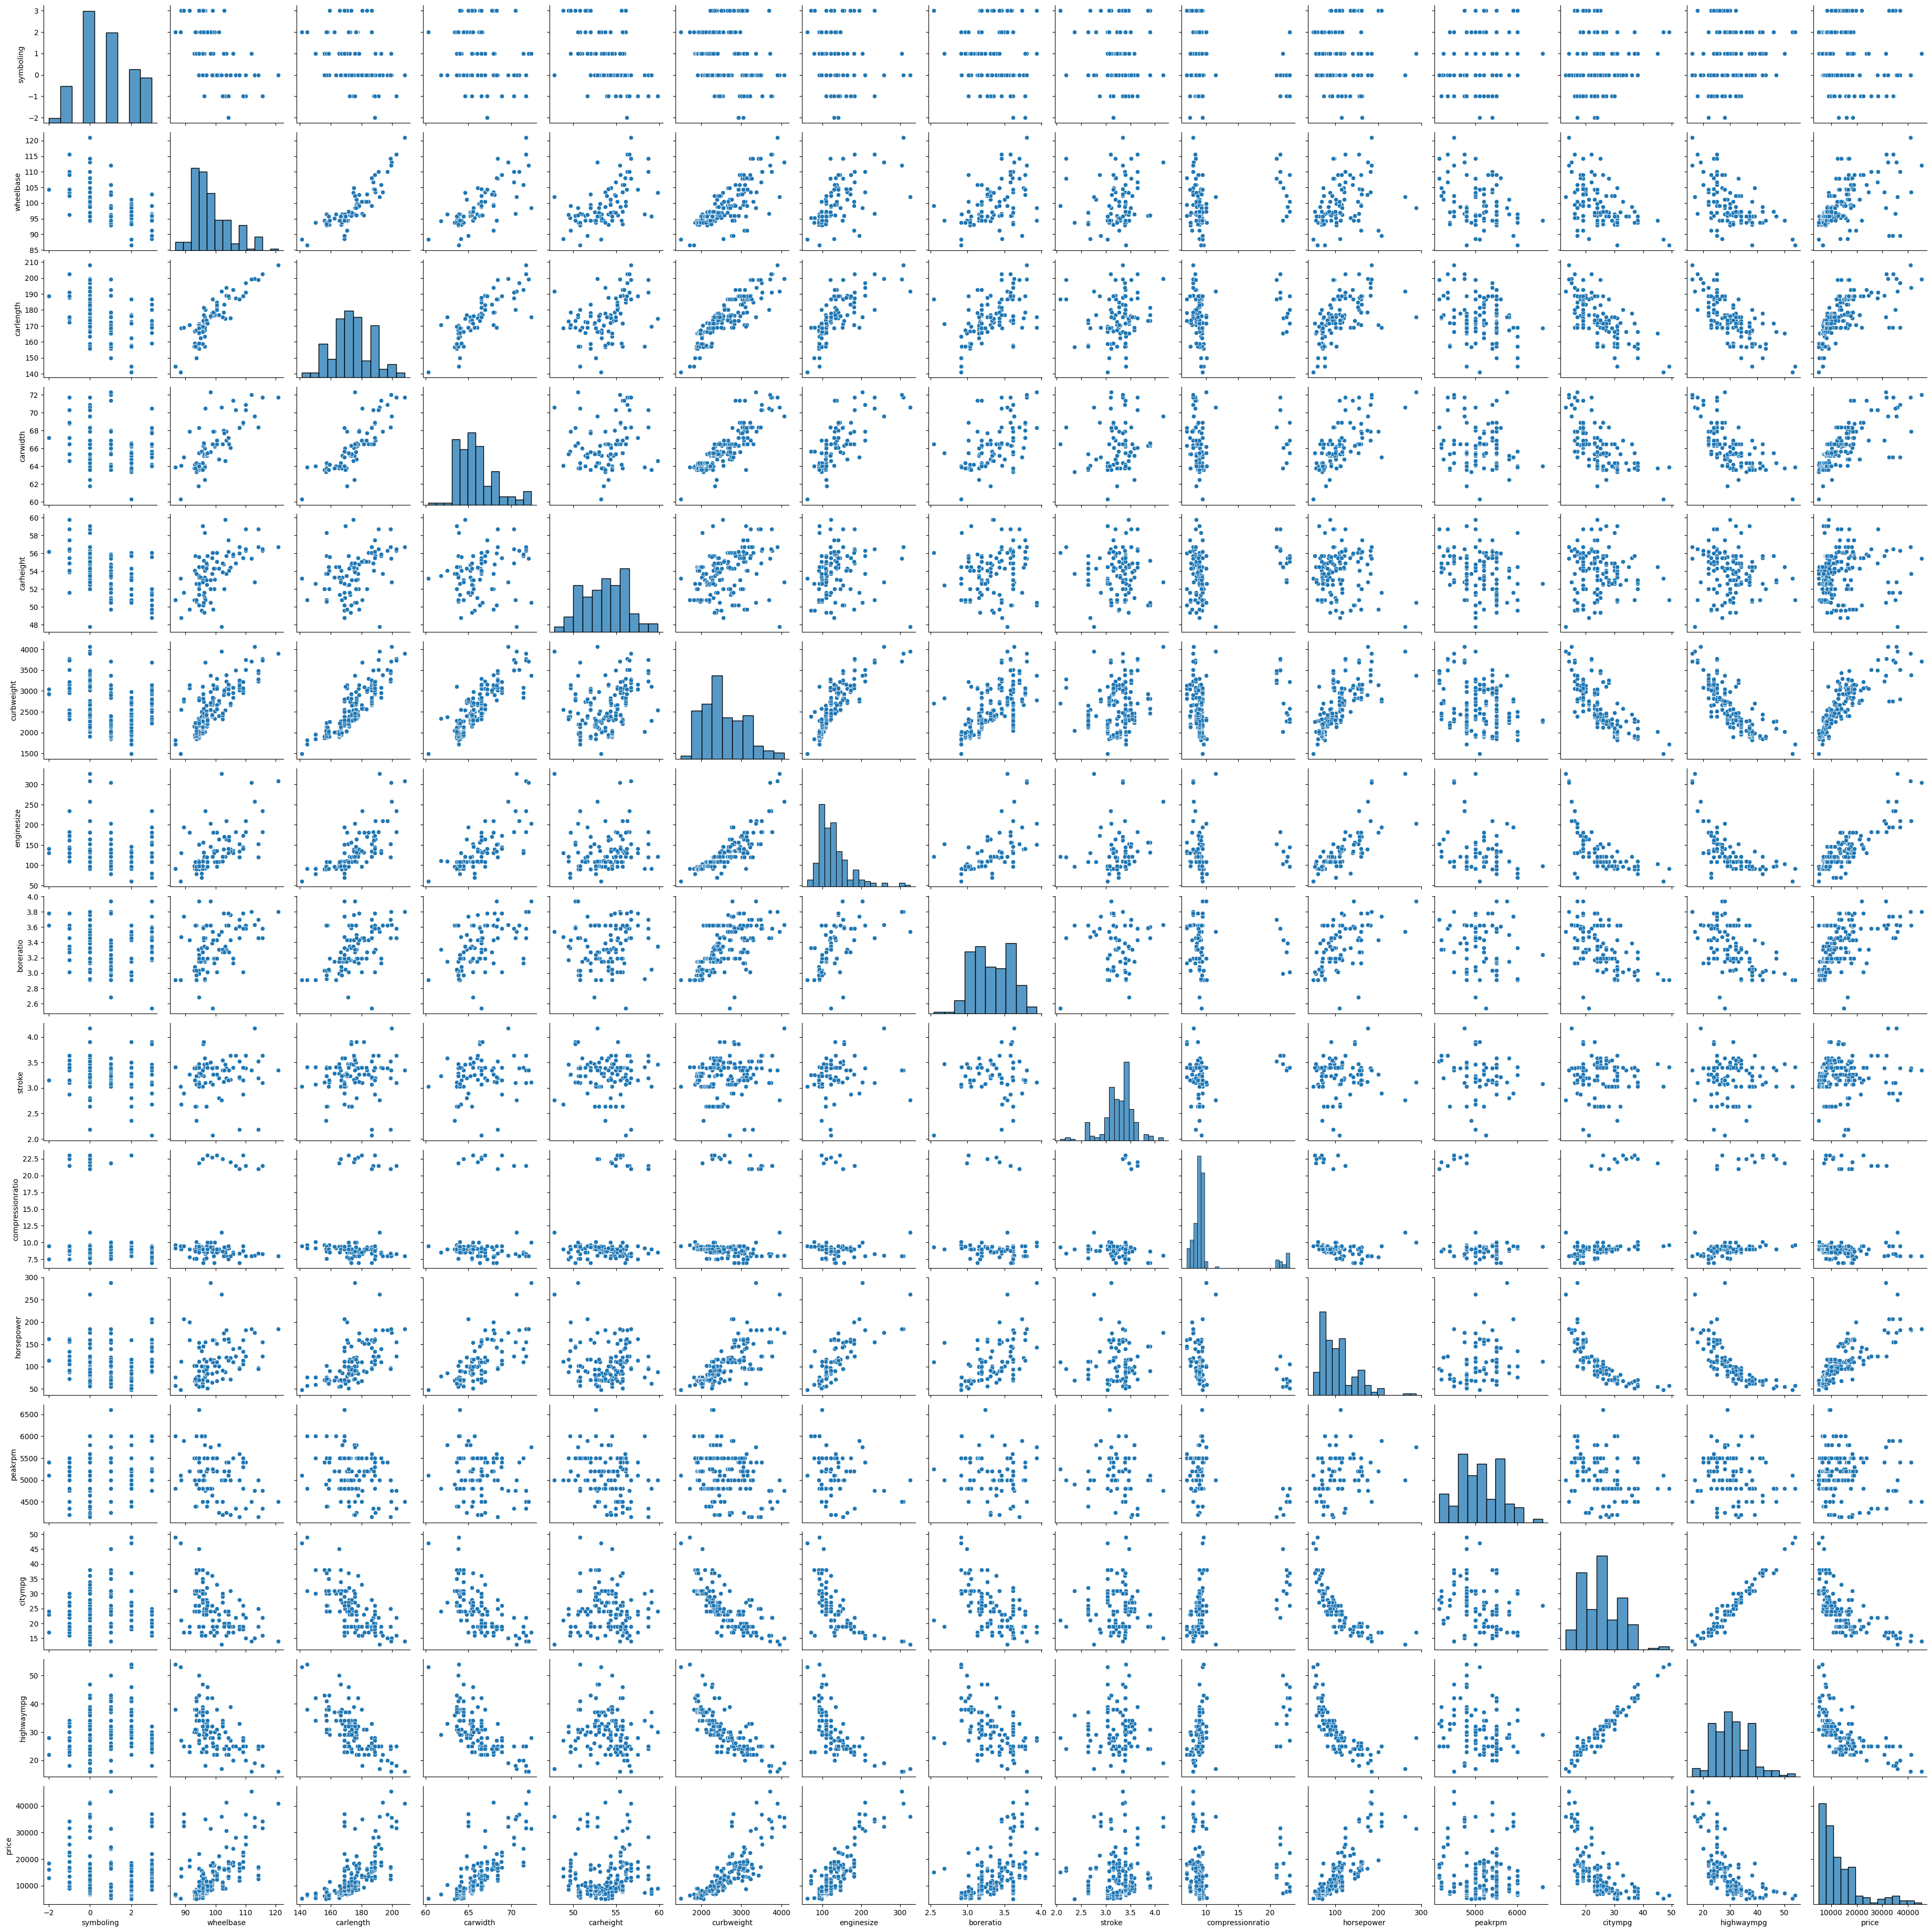

In [155]:
sns.pairplot(df_num)

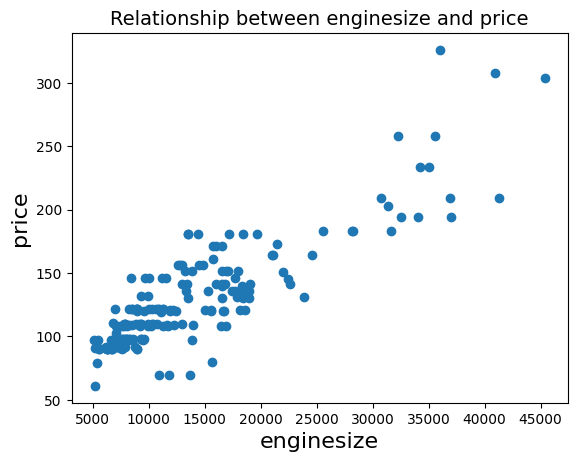

In [156]:
plt.scatter(df_num['price'], df_num['enginesize'])
plt.xlabel('enginesize', fontsize=16)
plt.ylabel('price', fontsize=16)
plt.title("Relationship between enginesize and price", fontsize=14)
plt.show()

### Ejercicio 2

Identifica la variable target y asignala a una variable de nombre `target`, luego elimina de forma permanente el campo "car_ID"

In [157]:
target = 'price'

### Ejercicio 3

Haz un split del dataset en train y test al 80/20 empleando la función de sklearn que ya conoces

In [158]:
df
print(df.fueltype.unique())
print(df.enginelocation.unique())
print(df.aspiration.unique())
print(df.doornumber.unique())
print(df.carbody.unique())
print(df.drivewheel.unique())
print(df.fuelsystem.unique())
print(df.cylindernumber.unique())
print(df.enginetype.unique())

<StringArray>
['gas', 'diesel']
Length: 2, dtype: str
<StringArray>
['front', 'rear']
Length: 2, dtype: str
<StringArray>
['std', 'turbo']
Length: 2, dtype: str
<StringArray>
['two', 'four']
Length: 2, dtype: str
<StringArray>
['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop']
Length: 5, dtype: str
<StringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str
<StringArray>
['mpfi', '2bbl', 'mfi', '1bbl', 'spfi', '4bbl', 'idi', 'spdi']
Length: 8, dtype: str
<StringArray>
['four', 'six', 'five', 'three', 'twelve', 'two', 'eight']
Length: 7, dtype: str
<StringArray>
['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf', 'dohcv']
Length: 7, dtype: str


In [159]:
df_num.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [160]:
# X = df_num.drop(columns=[target])
# y = df_num[target]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# print(f"Train: {X_train.shape}, {y_train.shape} | Test: {X_test.shape}, {y_test.shape}")

### Ejercicio 4

Aunque vamos a emplear todas las variabes numéricas del dataset como predictores o features, obten la correlación de todas ellas con el target y escoge los que creas que son tus tres mejores predictores. Crea una lista con los nombres de las variables numéricas y llámalo `features_num`

In [161]:
features_num = df_num.columns

features_num

Index(['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='str')

In [162]:
# lr = linear_model.LinearRegression()

# lr.fit(X_train, y_train)

# y_pred = lr.predict(X_test)
# baseline_error = metrics.mean_squared_error(y_test, y_pred)

# print("Train MSE:", metrics.mean_squared_error(y_train, lr.predict(X_train)))
# print("Test MSE:", metrics.mean_squared_error(y_test, lr.predict(X_test)))
# print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, lr.predict(X_test))))

<Axes: >

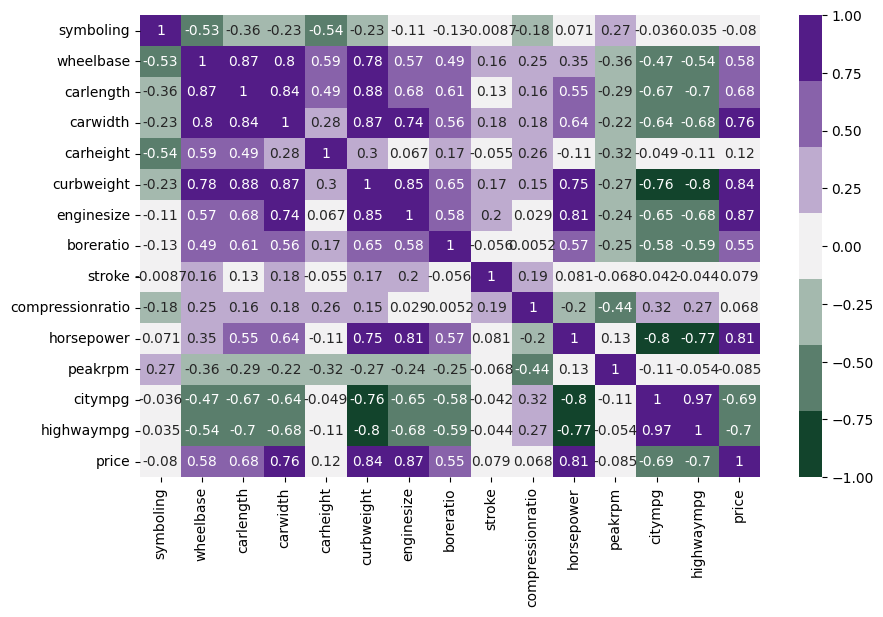

In [163]:
corr = df_num.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
    annot=True
)

In [164]:
df_3 = df_num[['enginesize', 'curbweight', 'horsepower', 'price']]
df_3

,enginesize,curbweight,horsepower,price
0,130,2548,111,13495.0
1,130,2548,111,16500.0
2,152,2823,154,16500.0
3,109,2337,102,13950.0
4,136,2824,115,17450.0
...,...,...,...,...
200,141,2952,114,16845.0
201,141,3049,160,19045.0
202,173,3012,134,21485.0
203,145,3217,106,22470.0


<Axes: >

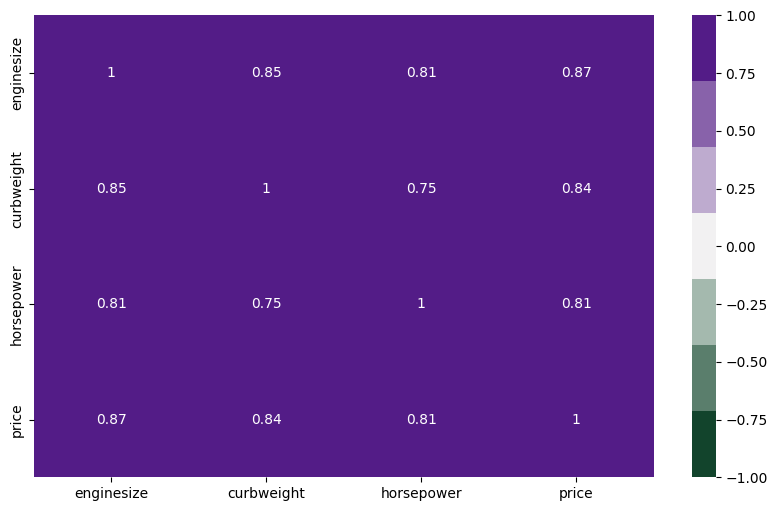

In [165]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df_3.corr(),
    vmin=-1,
    vmax=1,
    cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
    annot=True
)

*Así de primeras parece que nos quedaríamos el tamaño del motor, la potencia en caballos y el curbweight (el peso en vacío), luego lo comprobaremos al pintar los pesos*

### Ejercicio 5

Completa el siguiente código que tiene como objetivo generar un modelo de regresión lineal utilizando todos los valores de las variables (salvo la target):

In [ ]:

train_set = pd.concat([X_train, y_train], axis=1)
test_set = pd.concat([X_test, y_test], axis=1)

X_train = train_set.drop(columns=[target])
y_train = train_set[target]

X_test = test_set.drop(columns=[target])
y_test = test_set[target]

# X_train = pd.DataFrame(scaler.fit_transform(X_train[features_num]), columns= features_num)
# X_test = pd.DataFrame(scaler.transform(________[___________]), columns= features_num)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  


lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)


def get_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"{model_name} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


y_train_pred_lin = lin_reg.predict(X_train_scaled)
metrics_lin = get_metrics(y_train, y_train_pred_lin, "Lineal")

Lineal | MAE: 2186.50 | RMSE: 2911.59 | R²: 0.8579 | MAPE: 0.1691


In [167]:
print(f"Features: {X_train.shape[1]}")
print(f"R² train: {lin_reg.score(X_train, y_train):.3f}")
print(f"R² test: {lin_reg.score(X_test, y_test):.3f}")

Features: 14
R² train: -1038576.508
R² test: -761070.540


### Ejercicio 6

Obten el MAE,RMSE y $R^2$ para las predicciones sobre train (X_train) y para las predicciones sobre test (X_test). ¿Podemos esperar una buena generalización?

In [168]:
y_train_pred = lin_reg.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

*Para Train*

In [169]:
print("TRAIN:  MAE={:.0f}  RMSE={:.0f}  R²={:.3f}".format(mae_train, rmse_train, r2_train))


TRAIN:  MAE=7844527  RMSE=7870103  R²=-1038576.508


*Para Test*

In [170]:
y_test_pred = lin_reg.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [171]:
print("TEST:   MAE={:.0f}  RMSE={:.0f}  R²={:.3f}".format(mae_test, rmse_test, r2_test))

TEST:   MAE=7731706  RMSE=7751261  R²=-761070.540


*Ha empeorado en todas las métricas, con un MAPE por ejemplo que ha subido hasta el 24%, y el RMSE también ha aumentado un porcetanje sensible. No es muy mala generalización pero podríamos intentar mejorarla. Veamos que tal con la regularización*

### Ejercicio 7
 
Vamos a regularizar, crea un regresor Ridge con alpha inicial a 10 y entrenalo con el X_train. Obten MAE, RMSE y $R^2$ considerando las predicciones sobre el mismo X_train

In [172]:
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [173]:
y_train_ridge_pred = ridge.predict(X_train)

In [174]:
mae_train_ridge = mean_absolute_error(y_train, y_train_ridge_pred)
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_ridge_pred))
r2_train_ridge = r2_score(y_train, y_train_ridge_pred)

In [175]:
print("RIDGE (alpha=10) sobre TRAIN:")
print(f"MAE:  ${mae_train_ridge:.0f}")
print(f"RMSE: ${rmse_train_ridge:.0f}")
print(f"R²:   {r2_train_ridge:.3f}")

RIDGE (alpha=10) sobre TRAIN:
MAE:  $2205
RMSE: $2938
R²:   0.855


### Ejercicio 8

Evalúalo contra el X_test y obten MAE,RMSE y $R^2$. ¿Es mejor generalizado que la regresión lineal sin regularizar?

In [176]:
y_test_ridge_pred = ridge.predict(X_test)

mae_test_ridge = mean_absolute_error(y_test, y_test_ridge_pred)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_ridge_pred))
r2_test_ridge = r2_score(y_test, y_test_ridge_pred)

In [177]:
print("RIDGE (alpha=10) sobre TEST:")
print(f"MAE:  ${mae_test_ridge:.0f}")
print(f"RMSE: ${rmse_test_ridge:.0f}")
print(f"R²:   {r2_test_ridge:.3f}")

RIDGE (alpha=10) sobre TEST:
MAE:  $2679
RMSE: $3767
R²:   0.820


*Observa las diferencias entre train y test para este caso y la regresión lineal sin regularizar, es ligeramente mejor la generalización del Ridge*

### Ejercicio 9
 
Ahora crea un regresor Lasso con alpha inicial a 125 y entrenalo con el X_train. Obten MAE, RMSE y $R^2$ considerando las predicciones sobre el mismo X_train.

In [178]:
lasso = Lasso(alpha=125, max_iter=5000)  
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",125
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",5000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [179]:
y_train_lasso_pred = lasso.predict(X_train)

In [180]:
mae_train_lasso = mean_absolute_error(y_train, y_train_lasso_pred)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_train_lasso_pred))
r2_train_lasso = r2_score(y_train, y_train_lasso_pred)

In [181]:
print("LASSO (alpha=125) sobre TRAIN:")
print(f"MAE:  ${mae_train_lasso:.0f}")
print(f"RMSE: ${rmse_train_lasso:.0f}")
print(f"R²:   {r2_train_lasso:.3f}")


LASSO (alpha=125) sobre TRAIN:
MAE:  $2196
RMSE: $2961
R²:   0.853


### Ejercicio 10

Evalúalo contra el X_test y obten MAE,RMSE y $R^2$. ¿Es mejor generalizado que los otros dos modelos?

In [182]:
y_test_lasso_pred = lasso.predict(X_test)

mae_test_lasso = mean_absolute_error(y_test, y_test_lasso_pred)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_test_lasso_pred))
r2_test_lasso = r2_score(y_test, y_test_lasso_pred)

print("LASSO (alpha=125) sobre TEST:")
print(f"MAE:  ${mae_test_lasso:.0f}")
print(f"RMSE: ${rmse_test_lasso:.0f}")
print(f"R²:   {r2_test_lasso:.3f}")

LASSO (alpha=125) sobre TEST:
MAE:  $2689
RMSE: $3748
R²:   0.822


*Mejora la regresión lineal pero no es especialmente mejor que la Ridge*

### Ejercicio 11

Repite los ejercicios 9 y 10 con un regresos ElasticNet con alpha 0.2 y l1_ratio a 0.7. ¿Es mejor generalizando que el resto?

In [183]:
elastic = ElasticNet(alpha=0.2, l1_ratio=0.7, max_iter=5000)
elastic.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.2
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.7
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",5000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [184]:
y_train_elastic_pred = elastic.predict(X_train)
mae_train_elastic = mean_absolute_error(y_train, y_train_elastic_pred)
rmse_train_elastic = np.sqrt(mean_squared_error(y_train, y_train_elastic_pred))
r2_train_elastic = r2_score(y_train, y_train_elastic_pred)

In [185]:
print("ELASTICNET (α=0.2, l1=0.7) TRAIN:")
print(f"MAE:  ${mae_train_elastic:.0f}")
print(f"RMSE: ${rmse_train_elastic:.0f}")
print(f"R²:   {r2_train_elastic:.3f}")

ELASTICNET (α=0.2, l1=0.7) TRAIN:
MAE:  $2205
RMSE: $2938
R²:   0.855


In [186]:
y_test_elastic_pred = elastic.predict(X_test)
mae_test_elastic = mean_absolute_error(y_test, y_test_elastic_pred)
rmse_test_elastic = np.sqrt(mean_squared_error(y_test, y_test_elastic_pred))
r2_test_elastic = r2_score(y_test, y_test_elastic_pred)

In [187]:
print("\nELASTICNET (α=0.2, l1=0.7) TEST:")
print(f"MAE:  ${mae_test_elastic:.0f}")
print(f"RMSE: ${rmse_test_elastic:.0f}")
print(f"R²:   {r2_test_elastic:.3f}")


ELASTICNET (α=0.2, l1=0.7) TEST:
MAE:  $2679
RMSE: $3767
R²:   0.820


*Termina pareciéndose a las anteriores. Tendríamos que optimizar los hiperparámetros alpha y l1_ratio en este caso. Y el alpha en las otras dos regularizaciones*

### Ejercicio 12

¿Qué podrías hacer para mejorar los regresores regularizados?

Se podrían modificar los hiperparámetros para tener la configuración perfecta de Ridge, Lasso o Elastic Net (su combinación). Quizás una elastic net concreta consiga el resultado más óptimo. 

Seleccionar las features más relevantes, quizás hacer combincaciones de algunas para amplificar su importancia. Puede que Ridge elimine features que no lo parecen pero son importantes. 

Bueno, y no hemos utilizado ninguna columna no numerica, que hace que estemos ignorando un montón de factores. De hecho creo que son de las más importantes. (marca del coche asumo que influirá muchisimo en el precio, o cylindernumber, o aspiration)

### EXTRA:

Utiliza la función siguiente para pintar la importancia de los coeficientes en cada uno de los cuatro modelos y observa el efecto de las penalizaciones de cada una de las regularizaciones:

In [188]:
def show_coefs(model, figsize=(10, 5)):
    df_coef = pd.DataFrame(model.coef_, index=model.feature_names_in_, columns=["coefs"])

    fig, ax = plt.subplots(1, 2, figsize=figsize)
    df_coef.plot(kind="barh", ax=ax[0], legend=False)
    df_coef.abs().sort_values(by="coefs").plot(kind="barh", ax=ax[1], legend=False)
    fig.suptitle("Model Coefficients")

    fig.tight_layout()

    return df_coef

In [189]:
X_train_df = pd.DataFrame(X_train, columns=features_num)
X_test_df = pd.DataFrame(X_test, columns=features_num)

*La función muestra dos gráficos de barras horizontales, el de la izquierda con valor y signo el de la derecha solo con el valor de los coeficientes*

**Regresion_Lineal**

,coefs
symboling,208.925033
wheelbase,140.385781
carlength,-77.847289
carwidth,525.580891
carheight,201.090018
curbweight,0.445754
enginesize,123.348827
boreratio,-363.203632
stroke,-3188.132914
compressionratio,361.030613


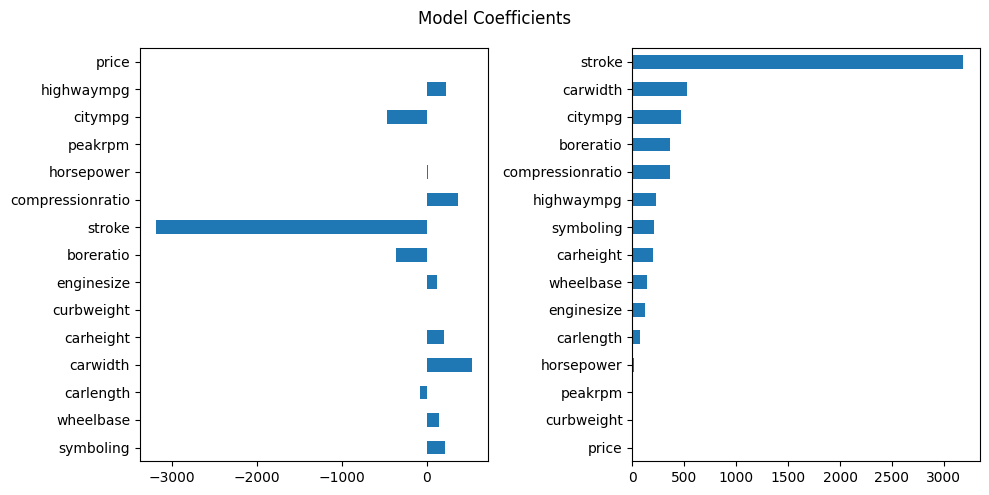

In [195]:
X_train_df = X_train_df.fillna(X_train_df.mean())
lin_reg.fit(X_train_df, y_train)
show_coefs(lin_reg)

,coefs
symboling,208.925033
wheelbase,140.385781
carlength,-77.847289
carwidth,525.580891
carheight,201.090018
curbweight,0.445754
enginesize,123.348827
boreratio,-363.203632
stroke,-3188.132914
compressionratio,361.030613


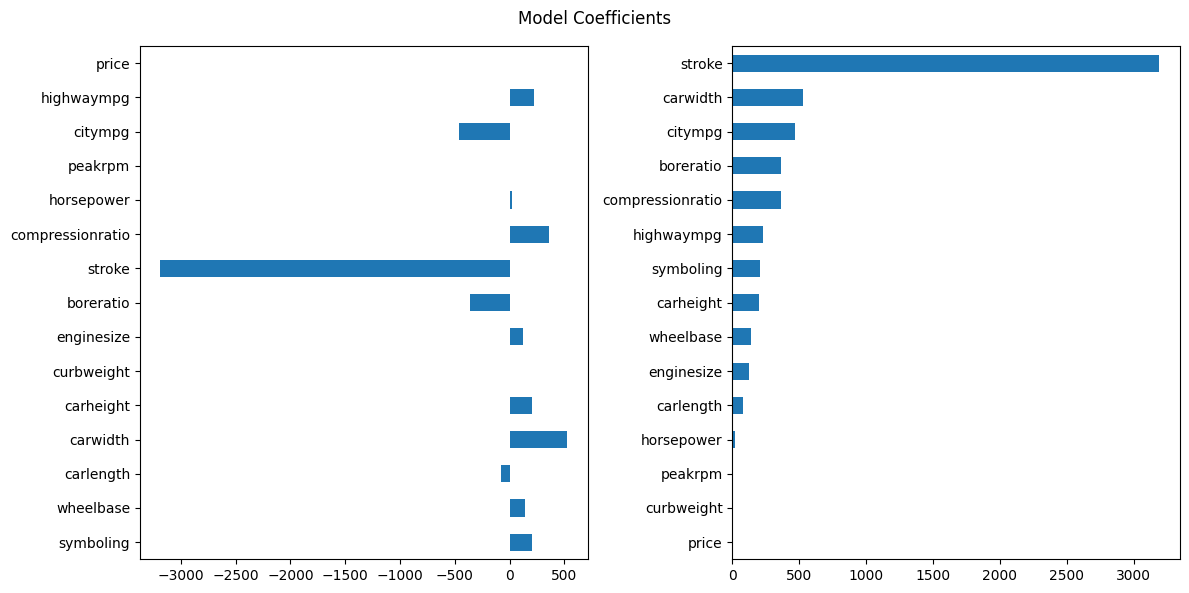

In [191]:
show_coefs(lin_reg, figsize=(12, 6))

**Ridge**

,coefs
symboling,213.125097
wheelbase,115.048071
carlength,-71.714755
carwidth,501.399250
carheight,227.377704
curbweight,0.550585
enginesize,117.984201
boreratio,-27.155993
stroke,-1846.909394
compressionratio,335.106540


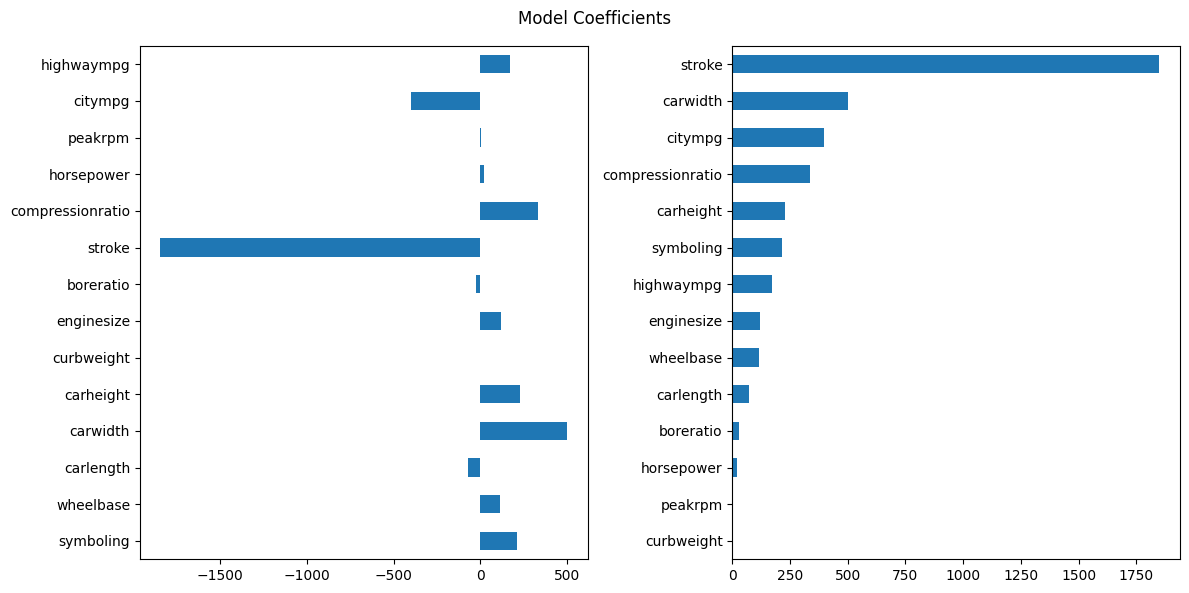

In [192]:
show_coefs(ridge, figsize=(12, 6))

*Observa la diferencia de los coeficientes a la derecha comparados con la regresión lineal, son los mismos pero suavizados, en algún caso en sobremedida (seguramente por ser colineal con otro), como es el caso de `highwaympg`*

**Lasso**

,coefs
symboling,86.452087
wheelbase,65.879954
carlength,-40.296433
carwidth,437.825009
carheight,169.644435
curbweight,0.750867
enginesize,114.220053
boreratio,0.000000
stroke,-1631.621680
compressionratio,311.504586


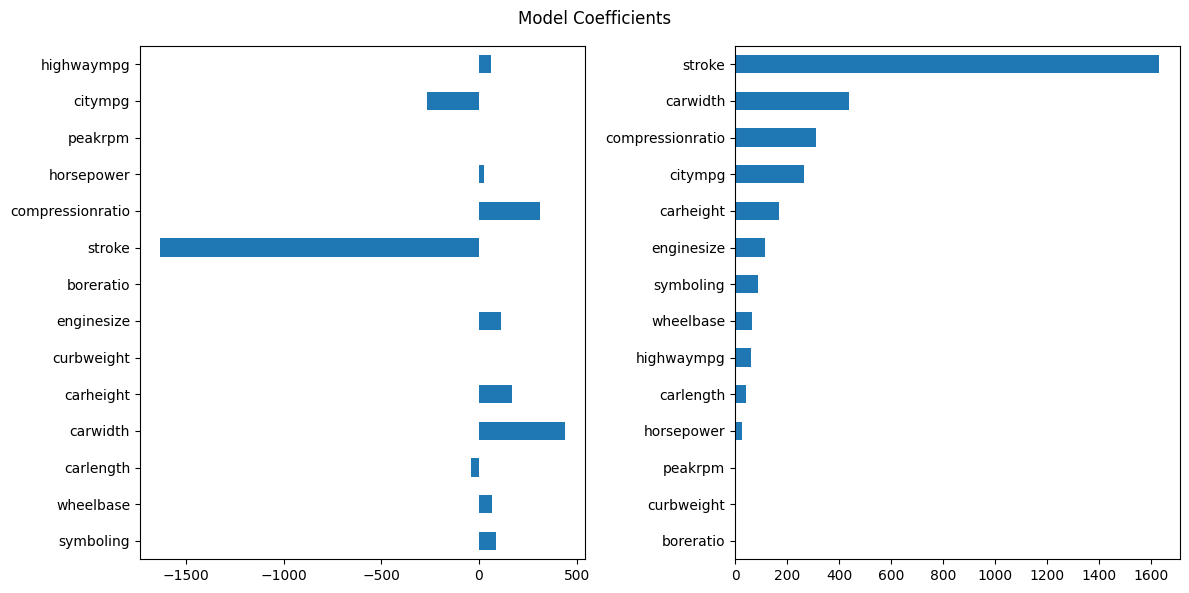

In [193]:
show_coefs(lasso, figsize=(12, 6))

*En cambio, esta regularización no suaviza directamente selecciona, mira lo que ha ocurrido con los coeficientes con menores pesos en la regresión lineal, en esta al entrenar se los ha cepillado (coeficiente a cero, fíjate en los cinco últimos de la derecha). El efecto selección de features se ve claramente.*

**ElasticNet**

,coefs
symboling,213.004827
wheelbase,115.203645
carlength,-71.764781
carwidth,501.725419
carheight,227.144828
curbweight,0.549534
enginesize,118.031325
boreratio,-26.936132
stroke,-1858.260163
compressionratio,335.320250


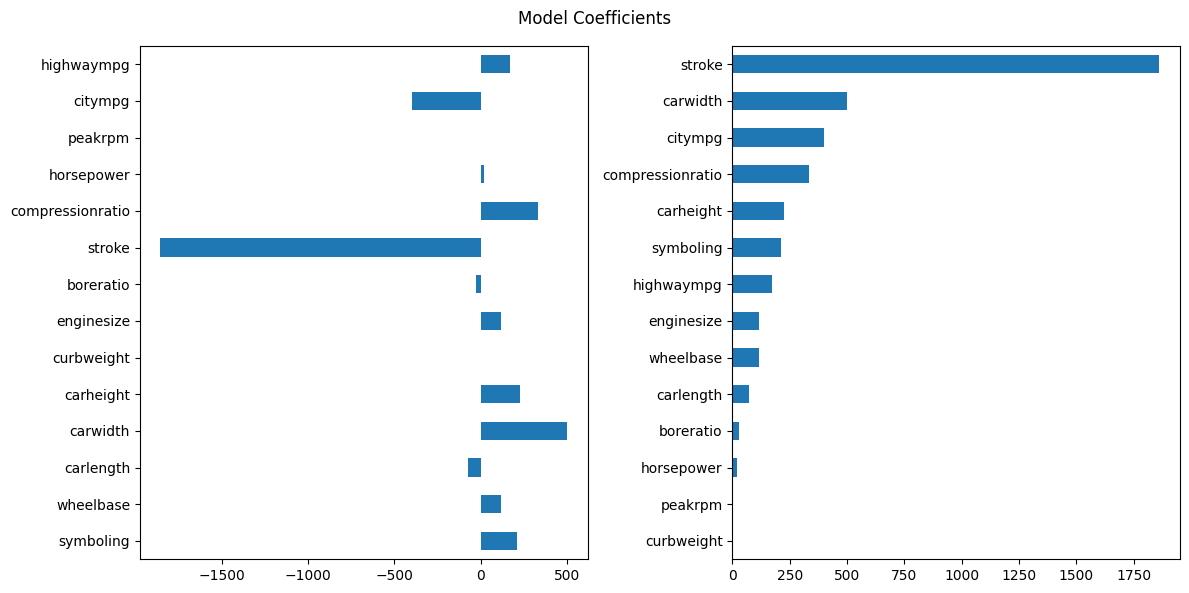

In [194]:
show_coefs(elastic, figsize=(12, 6))

*Como era de esperar se ha hecho una mezcla de suavizado y selección, y aun a pesar del alto valor de L1, ha suavizado más que seleccionado*